In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('./data/twitter_training.csv')

In [13]:
val_df = pd.read_csv('./data/twitter_validation.csv')

In [5]:
df['tweet_content'].values

array(['I am coming to the borders and I will kill you all,',
       'im getting on borderlands and i will kill you all,',
       'im coming on borderlands and i will murder you all,', ...,
       'Just realized the windows partition of my Mac is now 6 years behind on Nvidia drivers and I have no idea how he didn’t notice',
       'Just realized between the windows partition of my Mac is like being 6 years behind on Nvidia drivers and cars I have no fucking idea how I ever didn ’ t notice',
       'Just like the windows partition of my Mac is like 6 years behind on its drivers So you have no idea how I didn’t notice'],
      dtype=object)

In [4]:
print(df.duplicated().sum())


2339


In [14]:
df1 = df.copy()

In [2]:
# %pip install spacy
# !python -m spacy download en_core_web_lg

import spacy
nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])

In [6]:
df1['tweet_content'].sample(5).values

array(['Credit: @ HNSOfficial _ @ ModernWarzone', "Can't wait",
       'dont do this again',
       "i forgot how bad is the graphic in first assassin's creed, my eyes are burning",
       'I would love to pay for @ EASPORTSFIFA 21 if there was no update other than removing this screen... Why is it still there? Why do you ask me every time I load the game? Why has it been this way for 10 years? pic.twitter.com / T3CBiosY9R'],
      dtype=object)

In [3]:
import contractions
import re
import emoji
from bs4 import BeautifulSoup

def preprocess_text(text):
    # Converts emoji to text
    text = emoji.demojize(text)
    text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags
    
    text = contractions.fix(text)  # Expand contractions
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # Reduce repeated characters
    text=re.sub(r"[@#^<>|(){}[\]\~*+=]", " ", text) # Remove less important special characters
    text=re.sub(r"\s+", " ", text)
    text = text.strip()  # Remove leading and trailing spaces
    return text

In [15]:
df1['tweet_content'] = df1['tweet_content'].apply(lambda x: preprocess_text(x))
val_df['tweet_content'] = val_df['tweet_content'].apply(lambda x: preprocess_text(x))

C:\Users\soura\AppData\Local\Temp\ipykernel_2660\142434363.py:9: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags


### Now, let's create a function to check if any of the rows contain only spaces or punctuations

In [16]:
def check_for_only_spaces_or_punctuations(text):
    # Check if the text contains only spaces or punctuation
    if not text or text.isspace() or re.match(r'^[\W_]+$', text):
        return True
    
    doc = nlp(text)
    
    if all (token.is_punct or token.is_space for token in doc):
        return True
    
    return False

In [17]:
df1['status'] = df1['tweet_content'].apply(check_for_only_spaces_or_punctuations)

In [11]:
df1[df1['status'] == True]

,ID,entity,sentiment,tweet_content,status
59,2411,Borderlands,Neutral,. .,True
60,2411,Borderlands,Neutral,..,True
62,2411,Borderlands,Neutral,..,True
351,2459,Borderlands,Positive,,True
585,2503,Borderlands,Neutral,. . . . . .,True
...,...,...,...,...,...
73245,9065,Nvidia,Negative,,True
73282,9073,Nvidia,Positive,,True
73729,9154,Nvidia,Positive,,True
73755,9161,Nvidia,Negative,,True


In [18]:
df1.drop(df1[df1['status'] == True].index, inplace=True)

In [19]:
df1['text_length'] = df1['tweet_content'].apply(lambda x: len(x.split()))

In [20]:
df1.groupby('sentiment')['text_length'].describe().T

sentiment,Irrelevant,Negative,Neutral,Positive
count,12803.000000,22238.000000,17972.000000,20540.000000
mean,19.925877,20.346569,20.370743,17.467235
std,14.370732,15.032366,14.020976,14.157219
min,1.000000,1.000000,1.000000,1.000000
25%,9.000000,8.000000,10.000000,7.000000
50%,16.000000,16.000000,17.000000,14.000000
75%,28.000000,29.000000,28.000000,24.000000
max,163.000000,189.000000,194.000000,167.000000


In [13]:
df1.head()

,ID,entity,sentiment,tweet_content,status,text_length
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,False,12
1,2401,Borderlands,Positive,i am getting on borderlands and i will kill yo...,False,11
2,2401,Borderlands,Positive,i am coming on borderlands and i will murder y...,False,11
3,2401,Borderlands,Positive,i am getting on borderlands 2 and i will murde...,False,13
4,2401,Borderlands,Positive,i am getting into borderlands and i can murder...,False,11


In [21]:
df1.drop(columns=['status','ID','text_length'], inplace=True)

In [22]:
df1.drop_duplicates(inplace=True)

In [23]:
df1.reset_index(drop=True, inplace=True)

In [24]:
val_df.drop(columns=['ID'], inplace=True)

In [25]:
df = df1.copy()

In [26]:
def lem(text_col, cat_col, data):
    data[text_col]=data[cat_col].astype(str)+" "+data[text_col].astype(str) # Concatenate the 'games' column content with the 'tweets' column content
    lemm=[" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(data[text_col], batch_size=256, n_process=-1)] # Perform lemmatization using spaCy's nlp.pipe for efficient batch processing
    return pd.Series(lemm, index=data.index)



In [27]:
df['lemmatized_text'] = lem('tweet_content', 'entity', df)

In [53]:
val_df['lemmatized_text'] = lem('tweet_content', 'entity', val_df)

In [4]:
def tokenize(text):
    tokens = []
    for token in nlp(text.lower()):
        tokens.append(token.text)
    return tokens

In [28]:
df['tokenized_text'] = df['lemmatized_text'].apply(tokenize)

In [54]:
val_df['tokenized_text'] = val_df['lemmatized_text'].apply(tokenize)

In [6]:
from collections import Counter

def word_occurrence(df):
    sentences = []
    for _ , row in df.iterrows():
        text = row['tokenized_text']   
       
        sentences.extend(text)
    
    vocab = {'<unk>': 0}
    
    for token in Counter(sentences):
        if token not in vocab:
            vocab[token] = len(vocab)
    
    return vocab
    
        

In [36]:
vocab = word_occurrence(df)

In [33]:
vocab

{'<unk>': 0,
 'borderland': 1,
 'i': 2,
 'be': 3,
 'come': 4,
 'to': 5,
 'the': 6,
 'border': 7,
 'and': 8,
 'will': 9,
 'kill': 10,
 'you': 11,
 'all': 12,
 ',': 13,
 'get': 14,
 'on': 15,
 'murder': 16,
 '2': 17,
 'into': 18,
 'can': 19,
 'borderlands': 20,
 'so': 21,
 'spend': 22,
 'a': 23,
 'few': 24,
 'hour': 25,
 'make': 26,
 'something': 27,
 'for': 28,
 'fun': 29,
 '.': 30,
 'if': 31,
 'do': 32,
 'not': 33,
 'know': 34,
 'huge': 35,
 'fan': 36,
 'maya': 37,
 'one': 38,
 'of': 39,
 'my': 40,
 'favorite': 41,
 'character': 42,
 'decide': 43,
 'myself': 44,
 'wallpaper': 45,
 'pc': 46,
 'here': 47,
 'original': 48,
 'image': 49,
 'versus': 50,
 'creation': 51,
 ':': 52,
 'enjoy': 53,
 '!': 54,
 'pic.twitter.com/mlsi5wf9jg': 55,
 'couple': 56,
 '..': 57,
 'that': 58,
 'picture': 59,
 'compare': 60,
 'have': 61,
 'pic.twitter.com': 62,
 '/': 63,
 'mlsi5wf9jg': 64,
 'rhandlerr': 65,
 '2010': 66,
 'rock': 67,
 '-': 68,
 'hard': 69,
 'la': 70,
 'varlope': 71,
 'rare': 72,
 '&': 73,
 'p

In [7]:
def replace_word_with_numbers(text):
    tokens = []
    for token in text:
        if token in vocab:
            tokens.append(vocab[token])
        else:
            tokens.append(vocab['<unk>'])
    return tokens

In [30]:
df['tokenized_text_in_numbers'] = df['tokenized_text'].apply(replace_word_with_numbers)

In [55]:
val_df['tokenized_text_in_numbers'] = val_df['tokenized_text'].apply(replace_word_with_numbers)

In [8]:
def padding(text):
    max_len = 200
    if len(text) > max_len:
        max_len = len(text)
    return text + [0] * (max_len - len(text))

In [38]:
df['tokenized_text_in_numbers'].apply(padding).values

array([list([1, 2, 3, 4, 5, 6, 7, 8, 2, 9, 10, 11, 12, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       list([1, 2, 3, 14, 15, 1, 8, 2, 9, 10, 11, 12, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [31]:
df['tokenized_text_in_numbers'] = df['tokenized_text_in_numbers'].apply(padding)

In [42]:
df['tokenized_text_in_numbers'].head()

0    [1, 2, 3, 4, 5, 6, 7, 8, 2, 9, 10, 11, 12, 13,...
1    [1, 2, 3, 14, 15, 1, 8, 2, 9, 10, 11, 12, 13, ...
2    [1, 2, 3, 4, 15, 1, 8, 2, 9, 16, 11, 12, 13, 0...
3    [1, 2, 3, 14, 15, 1, 17, 8, 2, 9, 16, 11, 2, 1...
4    [1, 2, 3, 14, 18, 1, 8, 2, 19, 16, 11, 12, 13,...
Name: tokenized_text_in_numbers, dtype: object

In [56]:
val_df['tokenized_text_in_numbers'] = val_df['tokenized_text_in_numbers'].apply(padding)

In [35]:
import json

with open('vocab.json', 'w') as f:
    json.dump(vocab, f)

In [5]:
def pad_sequence(seq, max_len=200, pad_value=0):
    """Pad a sequence to max_len unless it's longer, then keep its length."""
    # If sequence is longer than max_len, use its length instead
    if len(seq) > max_len:
        max_len = len(seq)
    return seq + [pad_value] * (max_len - len(seq))


In [7]:
pad_sequence([1, 2, 3], max_len=5, pad_value=0)

[1, 2, 3, 0, 0]

In [42]:
text_pipeline("Hello, I am happy to play game with you")

NameError: name 'lem_single' is not defined

In [57]:
X = df['tokenized_text_in_numbers']
y = df['sentiment']
X_val = val_df['tokenized_text_in_numbers']
y_val = val_df['sentiment']

In [58]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_lbl = label_encoder.fit_transform(y)

In [99]:
df['sentiment']

0        Positive
1        Positive
2        Positive
3        Positive
4        Positive
           ...   
69377    Positive
69378    Positive
69379    Positive
69380    Positive
69381    Positive
Name: sentiment, Length: 69382, dtype: object

In [108]:
label_encoder.inverse_transform(y_lbl)[50:70]

array(['Negative', 'Negative', 'Negative', 'Negative', 'Negative',
       'Neutral', 'Neutral', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Neutral'],
      dtype=object)

In [105]:
y_lbl[20:30]

array([3, 3, 1, 1, 1, 1, 1, 3, 3, 3])

In [ ]:
# 3-> positive, 2-> neutral, 1-> negative, 0 -> irrelevant

In [59]:
# Prepare the test data


y_val_lbl = label_encoder.transform(y_val)

### Now, we will use `class_weight` to address imbalanced target variables and avoid  further bias.

In [37]:
# import numpy as np
# from sklearn.utils import class_weight
# class_weights = class_weight.compute_class_weight('balanced', classes= np.unique(y_lbl), y=y_lbl)
# cw_dict = dict(enumerate(class_weights))
# cw_dict


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_lbl, random_state=42)

In [1]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [38]:
torch.cuda.device_count()

1

52036

In [39]:
X_train.iloc[8].values[0]

AttributeError: 'list' object has no attribute 'values'

In [50]:
import numpy as np

np.array(X.tolist()).shape

(69382, 200)

In [51]:
from torch.utils.data import Dataset

class NLPdataCustom(Dataset):
    
    def __init__(self, X_feature,y_label):
        
        # Convert to NumPy arrays first
        X_np = np.array(X_feature.tolist())  # Ensures 2D shape if Series contains lists
        y_np = np.array(y_label.tolist()) 
        
        
        self.X = torch.tensor(X_np ,dtype=torch.long)
        self.y = torch.tensor(y_np, dtype=torch.long)
        
        
    def __len__(self):
        return len(self.X)
    
    
    def __getitem__(self, index):
        X = self.X[index]
        y = self.y[index]
        
        return X, y
    



In [52]:
train_data_set = NLPdataCustom(X_train, y_train)
test_data_set = NLPdataCustom(X_test, y_test)

In [46]:
train_data_set.X.shape

torch.Size([52036, 200])

In [53]:
print("Unique labels:", train_data_set.y.unique())
print("Max label:", train_data_set.y.max().item())
print("Min label:", train_data_set.y.min().item())
print("Output classes expected:", len(train_data_set.y.unique()))


Unique labels: tensor([0, 1, 2, 3])
Max label: 3
Min label: 0
Output classes expected: 4


In [74]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_dataloader_custom = DataLoader(dataset=train_data_set,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     pin_memory=True)

test_dataloader_custom = DataLoader(dataset=test_data_set,
                                    batch_size=BATCH_SIZE,
                                    pin_memory=True,
                                  
                                    shuffle=False)

In [49]:
len(train_dataloader_custom), len(test_dataloader_custom)

(1627, 543)

In [50]:
len(train_data_set.y.unique())

4

In [66]:
class LSTMModelV1(nn.Module):

    def __init__(self, input_size, embedding_dim, hidden_size, layer_dim, drop_out, bi_directional , output_dim):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_dim = layer_dim
        self.embedding = nn.Embedding(input_size, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=layer_dim, bidirectional=bi_directional, dropout=drop_out)
        self.dropout = nn.Dropout(drop_out)
        self.linear = nn.Linear(hidden_size * 2 if bi_directional else hidden_size, output_dim) # Adjust linear layer size based on bidirectionality
        self.bi_directional = bi_directional


    def forward(self, x):

        num_directions = 2 if self.bi_directional else 1
        h0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size , device=device).requires_grad_()
        c0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size, device=device).requires_grad_()
        embedding = self.embedding(x)
        output ,(hidden, cell) = self.lstm(embedding, (h0.detach(), c0.detach()))

        if self.bi_directional:
             # hidden[-2,:,:] corresponds to the last layer's forward hidden state
            # hidden[-1,:,:] corresponds to the last layer's backward hidden state
            hidden_combined = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden_combined = self.dropout(hidden[-1,:,:]) # Use only the last layer's hidden state for unidirectional LSTM

        # hidden_combined: (batch_size, hidden_dim * 2)

        # Pass through fully connected layer to get the final prediction
        out =  self.linear(hidden_combined)

        return out

In [90]:
num_classes = len(np.unique(y_train))
num_classes

4

In [107]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
LSTMModel                                --
├─Embedding: 1-1                         3,304,300
├─LSTM: 1-2                              283,648
├─Dropout: 1-3                           --
├─Linear: 1-4                            516
Total params: 3,588,464
Trainable params: 3,588,464
Non-trainable params: 0

In [2]:
!nvidia-smi


Wed Aug  6 11:12:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.00                 Driver Version: 577.00         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce MX350         WDDM  |   00000000:2B:00.0 Off |                  N/A |
| N/A   60C    P3            N/A  / 5001W |       0MiB /   2048MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [77]:
def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device):
    
    
    
    model.train()
    
    train_loss, train_acc = 0, 0
    
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        # 1. Forward propagation
        y_pred = model(X)
        
        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        # 3. optimizer zero grad
        optimizer.zero_grad()
        
        # 4. loss backward
        loss.backward()
        
        # 5. optimizer step
        optimizer.step()
       
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
        
        
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    
    
    return train_loss, train_acc
        
        

In [60]:
def test_step(model,
              dataloader,
              loss_fn,
              device):
    
    
    
    model.eval()
    
    test_loss, test_acc = 0, 0
    
    
    with torch.inference_mode():
        for batch , (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            
            test_pred_logits = model(X)
            
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            test_pred_labels = test_pred_logits.argmax(dim=1)
            
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
            
            
           
    test_loss = test_loss / len(dataloader)
    
    test_acc = test_acc / len(dataloader)
    
    
    return test_loss, test_acc
            
            

In [69]:
torch.backends.cudnn.benchmark = True

In [79]:
from tqdm.auto import tqdm


def train(model,
          train_dataloader,
          test_dataloader,
          loss_fn,
          optimizer,
          epochs,
          device):
    
    
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss":[],
               "test_acc":[]}
    
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model,
                                           train_dataloader,
                                           loss_fn,
                                           optimizer,
                                           device)
        
        
        test_loss, test_acc = test_step(model,
                                        test_dataloader,
                                        loss_fn,
                                        device)
        
        
        print(f"Epoch: {epoch+1} |  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}" )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [82]:
model = LSTMModelV1(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=48,
                  layer_dim=3,
                  drop_out = 0.2,
                  bi_directional = True,
                  output_dim=len(train_data_set.y.unique())
                  ).to(device)



train_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.RMSprop(params=model.parameters(), lr=0.005981057556391124, weight_decay=1.019552870543316e-05)


model_results = train(model=model,
                      train_dataloader=train_dataloader_custom,
                      test_dataloader=test_dataloader_custom,
                      optimizer=optimizer,
                      loss_fn=train_loss_fn,
                      epochs=50,
                      device=device)

  2%|▏         | 1/50 [04:27<3:38:16, 267.27s/it]

Epoch: 1 |  Train loss: 1.0165 | Train acc: 0.5818 | Test loss: 0.7768 | Test acc: 0.7013


  4%|▍         | 2/50 [08:54<3:33:56, 267.42s/it]

Epoch: 2 |  Train loss: 0.5867 | Train acc: 0.7871 | Test loss: 0.5706 | Test acc: 0.7955


  6%|▌         | 3/50 [13:20<3:28:49, 266.59s/it]

...

Epoch: 48 |  Train loss: 0.0791 | Train acc: 0.9710 | Test loss: 0.3088 | Test acc: 0.9049


 98%|█████████▊| 49/50 [3:33:53<04:21, 261.77s/it]

Epoch: 49 |  Train loss: 0.0765 | Train acc: 0.9721 | Test loss: 0.3406 | Test acc: 0.9044


100%|██████████| 50/50 [3:38:20<00:00, 262.01s/it]

Epoch: 50 |  Train loss: 0.0775 | Train acc: 0.9728 | Test loss: 0.3277 | Test acc: 0.9072


In [83]:
from pathlib import Path 

model_path = Path('models')
model_path.mkdir(exist_ok=True)

save_model_path = model_path / 'modelV2.pth'

torch.save(model.state_dict(), save_model_path)


In [ ]:
save_model_path = './models/modelV2.pth'

from lstm_model import LSTMModelV1

model = LSTMModelV1(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=48,
                  layer_dim=3,
                  drop_out = 0.2,
                  bi_directional = True,
                  output_dim=4
                  ).to(device)

model.load_state_dict(torch.load(save_model_path))

<All keys matched successfully>

In [97]:
y_lbl

array([3, 3, 3, ..., 3, 3, 3])

In [94]:
def predict(model, X):
    model.eval()
    with torch.inference_mode():
    
        X = X.to(device)
        
        pred_logits = model(X)
        
        pred_labels = int(pred_logits.argmax(dim=1))
        
    return pred_labels
            

In [80]:
test_x = torch.tensor(sample_text, dtype=torch.long)

In [81]:
test_x.unsqueeze(0).shape

torch.Size([1, 200])

In [95]:
y = predict(model, test_x.unsqueeze(0))

In [96]:
y

1

In [84]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  loss = results["train_loss"]

  test_loss = results["test_loss"]

  accuracy = results["train_acc"]

  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

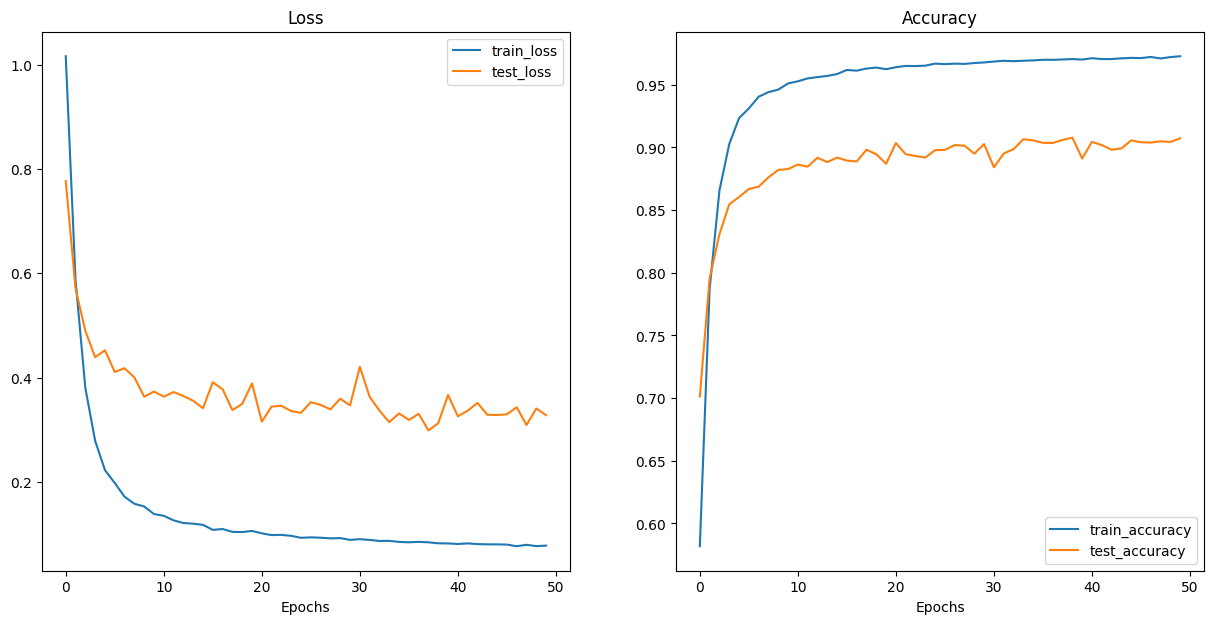

In [85]:
plot_loss_curves(model_results)

In [ ]:
import torchvision
def pred_and_plot_image(model: torch.nn.Module,
                        image_path = str,
                        class_names: List[str] = None,
                        transforms = None,
                        device =device):
    
    
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)
    
    target_image = target_image / 255, 
    
    if transforms:
        target_image = transforms(image)